In [23]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

In [2]:
df =pd.read_csv('Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
features = ['Pclass','Sex','Age','Fare','Embarked']
target = ['Survived']

In [9]:
from sklearn.impute import SimpleImputer

imp_median=SimpleImputer(strategy = 'median')
df[['Age']]=imp_median.fit_transform(df[['Age']])

imp_freq=SimpleImputer(strategy = 'most_frequent')
df[['Embarked']]=imp_freq.fit_transform(df[['Embarked']])

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Sex']=le.fit_transform(df['Sex'])
df['Embarked']=le.fit_transform(df['Embarked'])

In [17]:
X = df[features]
y = df[target]

In [18]:
X

,Pclass,Sex,Age,Fare,Embarked
0,3,1,28,7.2500,2
1,1,0,51,71.2833,0
2,3,0,34,7.9250,2
3,1,0,47,53.1000,2
4,3,1,47,8.0500,2
...,...,...,...,...,...
886,2,1,35,13.0000,2
887,1,0,24,30.0000,2
888,3,0,36,23.4500,2
889,1,1,34,30.0000,0


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state=42
)

In [22]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print("accuracy score", accuracy_score(y_test,y_pred))

accuracy score 0.7761194029850746


[Text(0.5, 0.875, 'Sex <= 0.5\ngini = 0.467\nsamples = 623\nvalue = [392, 231]\nclass = Died'),
 Text(0.25, 0.625, 'Pclass <= 2.5\ngini = 0.396\nsamples = 213\nvalue = [58, 155]\nclass = Survived'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Age <= 6.5\ngini = 0.07\nsamples = 110\nvalue = [4, 106]\nclass = Survived'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Fare <= 23.35\ngini = 0.499\nsamples = 103\nvalue = [54, 49]\nclass = Died'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Age <= 10.5\ngini = 0.302\nsamples = 410\nvalue = [334, 76]\nclass = Died'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Fare <= 27.562\ngini = 0.42\nsamples = 20\nvalue = [6, 14]\nclass = Survived'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Fare <= 52.277\ngini = 0.267\nsamples = 390\nvalue = [328.0, 62.0]\nclass = Died'),
 Text

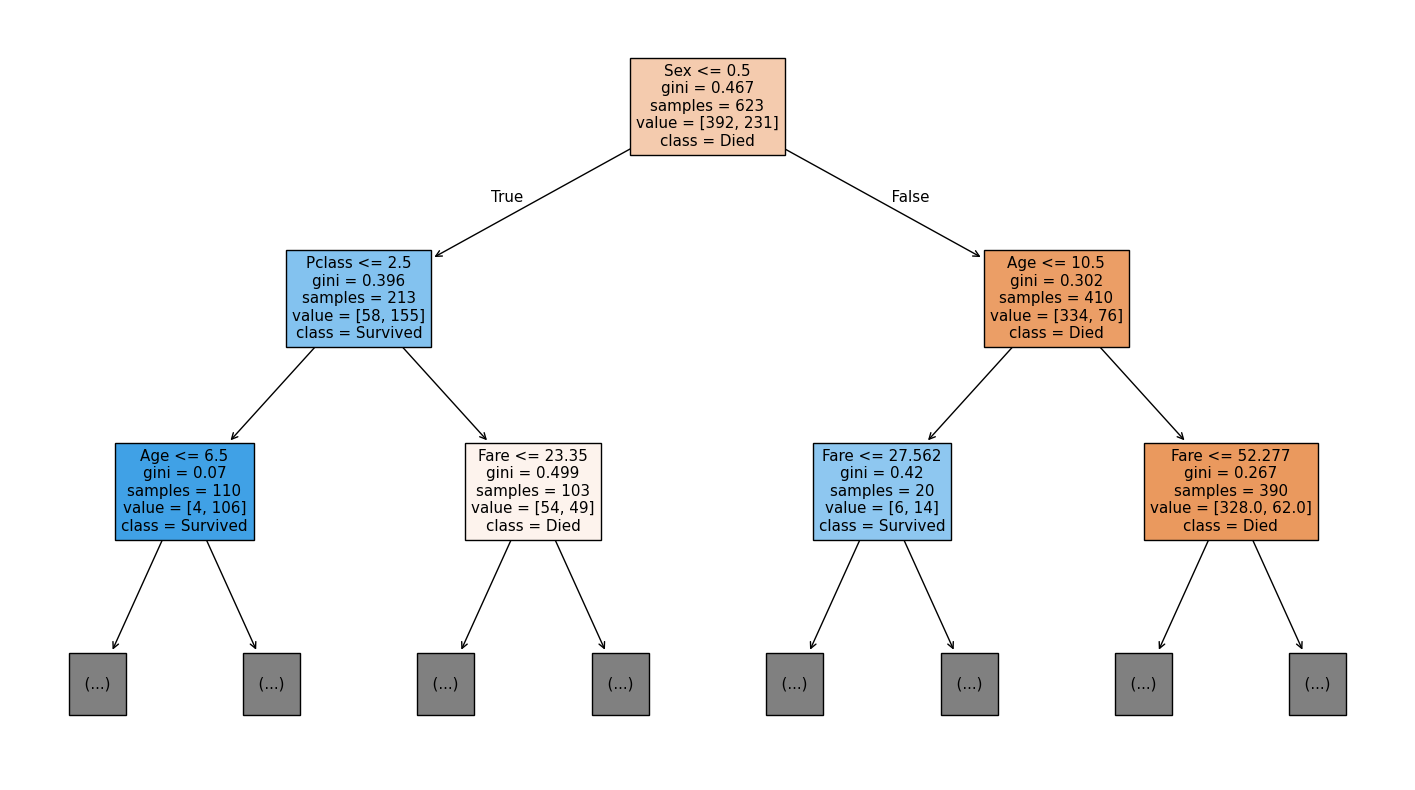

In [25]:
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names = X.columns,
    class_names =['Died','Survived'],
    filled =True,
    max_depth =2
)
    

# Decision Tree with Pre-Pruning


for depth = 2 , accuracy is 0.7723880597014925
for depth = 3 , accuracy is 0.8059701492537313
for depth = 4 , accuracy is 0.8246268656716418
accuracy 0.8246268656716418
for depth = 5 , accuracy is 0.7947761194029851
for depth = 6 , accuracy is 0.7835820895522388
for depth = 7 , accuracy is 0.7835820895522388
for depth = 8 , accuracy is 0.7947761194029851
for depth = 9 , accuracy is 0.7835820895522388
for depth = 10 , accuracy is 0.8022388059701493


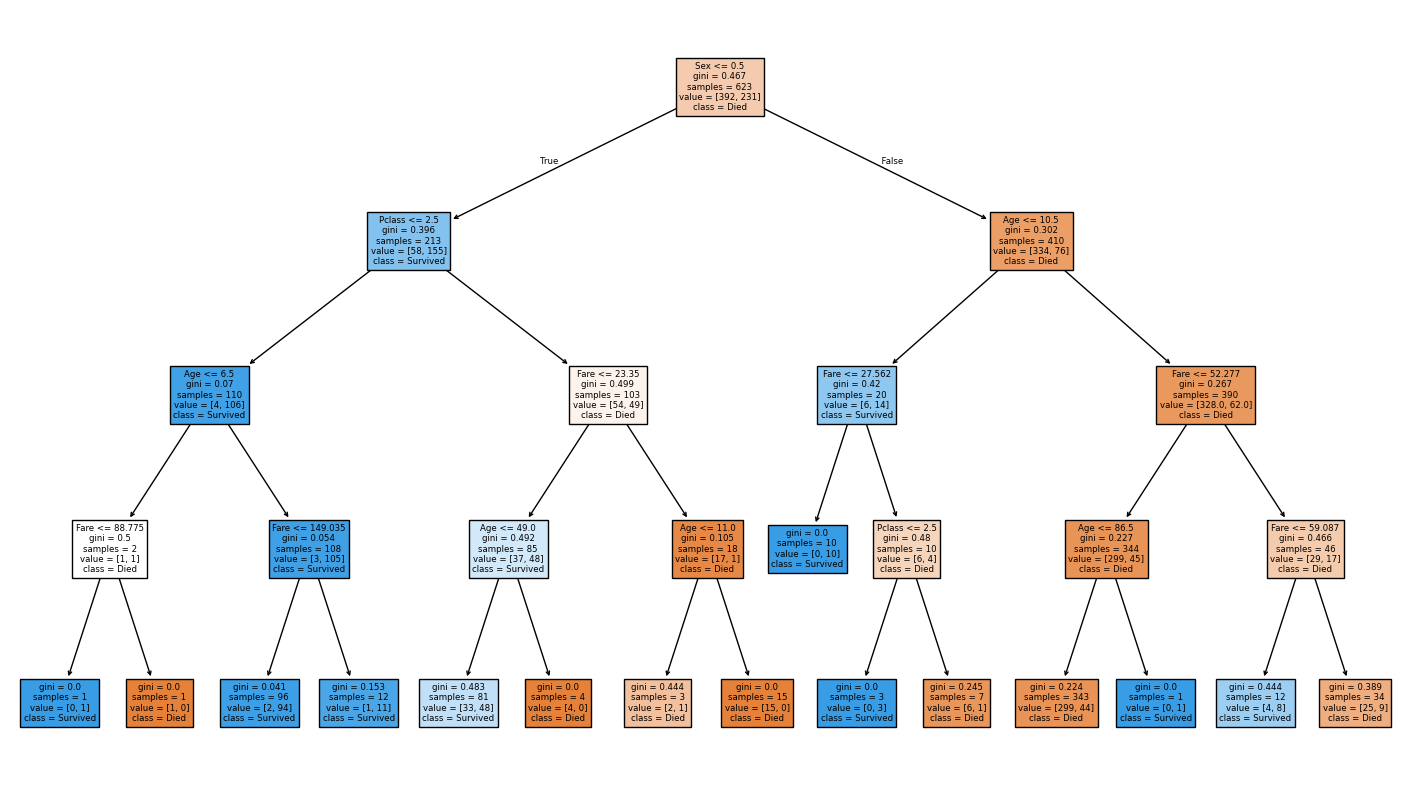

In [57]:
max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth:  
    model = DecisionTreeClassifier(max_depth =depth)
    model.fit(X_train,y_train)
    
    acc = model.score(X_test,y_test)
    print(f"for depth = {depth} , accuracy is {acc}")

    if depth == 4:
        y_pred = model.predict(X_test)
        print("accuracy",accuracy_score(y_test,y_pred))
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names =['Died','Survived'],
            filled = True
        )
        

for samples = 5 , accuracy is 0.8246268656716418
for samples = 10 , accuracy is 0.8246268656716418
for samples = 50 , accuracy is 0.8134328358208955
for samples = 100 , accuracy is 0.8097014925373134
for samples = 150 , accuracy is 0.7723880597014925
for samples = 200 , accuracy is 0.7723880597014925
for samples = 500 , accuracy is 0.7910447761194029
for samples = 800 , accuracy is 0.585820895522388
for samples = 890 , accuracy is 0.585820895522388


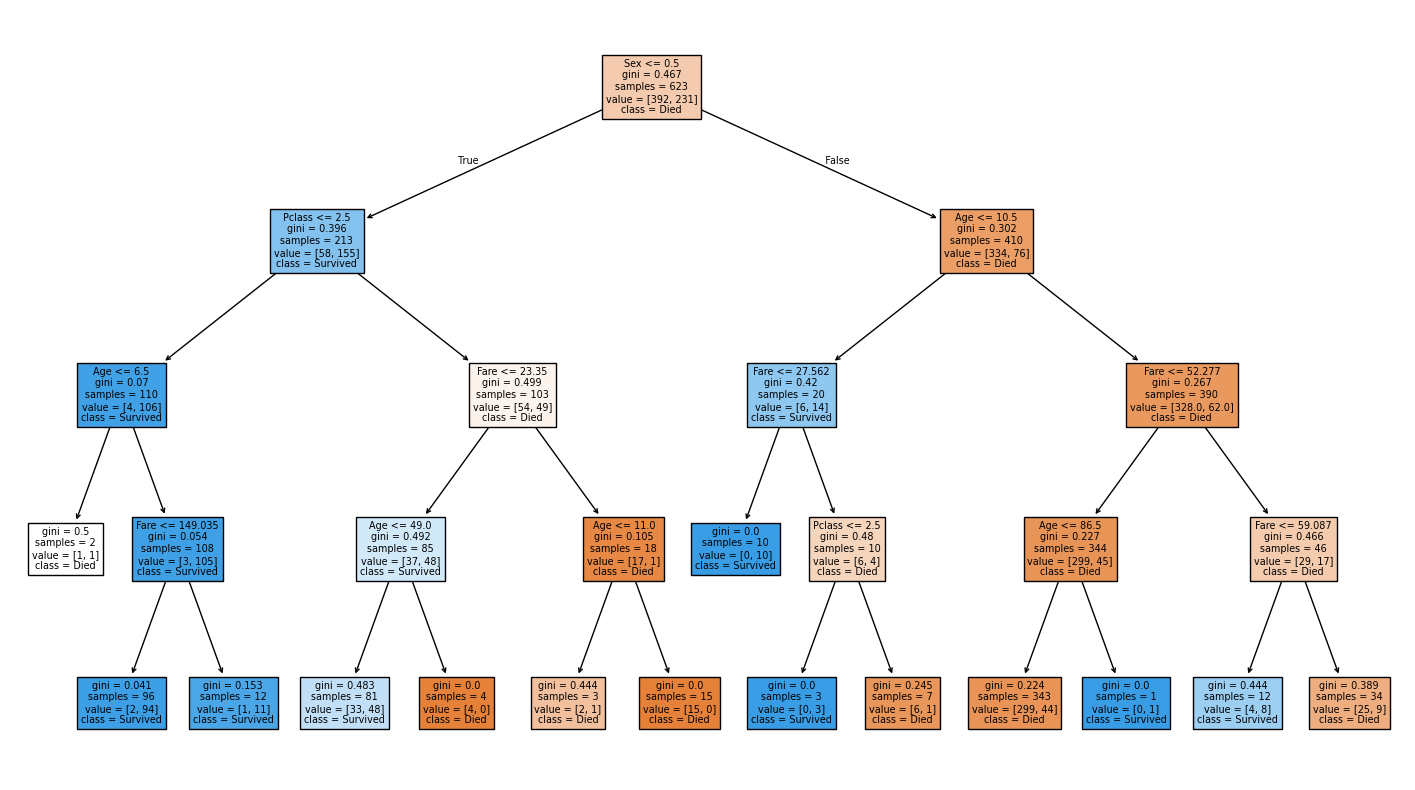

In [56]:
min_samples_split=[5,10,50,100,150,200,500,800,890]

for samples in min_samples_split:  
    model = DecisionTreeClassifier(max_depth=4,min_samples_split=samples)
    model.fit(X_train,y_train)

        
    acc = model.score(X_test,y_test)
    print(f"for samples = {samples} , accuracy is {acc}")
    
    if samples == 10:
        y_pred = model.predict(X_test)
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names =['Died','Survived'],
            filled = True
        )

# Decision Tree with Post-Pruning


In [60]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [63]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [73]:
# train our model for all alphas 
trees =[]
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state =42,ccp_alpha=alpha)
    model.fit(X_train,y_train)

    trees.append((model,alpha))
    #print(trees)

In [89]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    model.fit(X_train,y_train)
    curr_acc= model.score(X_test,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc 
        best_alpha = alpha


In [90]:
print("best alpha --> ",best_alpha  ,"best acc -->", best_acc)

best alpha -->  0.0017121455323702516 best acc --> 0.8246268656716418


Higher ccp_alpha values such as 0.04 and 0.13 impose strong complexity penalties, resulting in heavily pruned trees.
While this reduces overfitting, excessive pruning may cause underfitting.